In [1]:
import os, sys, tqdm
import numpy as np
import matplotlib.pyplot as plt
import anndata as ad
import scanpy as sc
import tifffile

from sklearn.decomposition import NMF

# Include src directory in the path dynamically
notebook_dir = os.path.abspath("")
src_path = os.path.join(notebook_dir, "../src")
sys.path.append(src_path)


import preprocessing.microscopy_image as mi
import preprocessing.raman as raman
from constants import ContainerEngine

## Constants Definition

In [2]:
PATH = "/staging/leuven/stg_00077/projects/Lorenzo/FOCUS/p_PDA/d_C1"
MODALITY_NAME = "Raman"
SAMPLE_ID_LIST = [
    "PDAC001T1",
    "PDAC001T2",
    "PDAC002N0",
    "PDAC002T1",
    "PDAC002T2",
    "PDAC003N0",
    "PDAC003T0",
    "PDAC004N0",
    "PDAC007N0",
    "PDAC007T1",
    "PDAC007T2",
    "PDAC010N0",
    "PDAC010T0",
    "PDAC011N0",
    "PDAC011T0",
]

MERGED_DATASET_PATH = os.path.join(PATH, "merged", "preprocessing", f"{MODALITY_NAME}_merged.h5ad")

## Prepare Raman Dataset and Load samples

In [3]:
samples: list[raman.RamanImage] = []

for sample_id in tqdm.tqdm(SAMPLE_ID_LIST, desc="Loading samples", unit="sample"):
    sample = raman.RamanImage(
        source_path=PATH,
        sample_id=sample_id,
        modality_name=MODALITY_NAME,
        container_engine=ContainerEngine.PODMAN,
    )
    samples.append(sample)

Loading samples: 100%|██████████| 15/15 [00:00<00:00, 18178.15sample/s]


## Process Raman Dataset

In [4]:
dataset = raman.RamanDataset(samples=samples)
processed_images = dataset.process_dataset(force_recomputing=True)

Processing sample: PDAC001T1
Loading Raman data from LIF file: 20251008_PDAC001T1.lif


Applying BaSiC Correction:   0%|          | 0/120 [00:54<?, ?it/s]


KeyboardInterrupt: 

## Visualize Processed Raman

In [17]:
def convert_to_rgb(image: np.ndarray) -> np.ndarray:
    """Raman hyperspectral images to RGB by performing NMF with 3 components and stacking them as channels."""
    
    nmf = NMF(n_components=3)
    H = nmf.fit_transform(image.reshape(-1, image.shape[-1]))
    W = nmf.components_
    rgb_image = H.reshape(image.shape[0], image.shape[1], 3)

    # Normalize each channel to [0, 1]
    rgb_image -= rgb_image.min(axis=(0, 1), keepdims=True)
    rgb_image /= rgb_image.max(axis=(0, 1), keepdims=True)
    return rgb_image

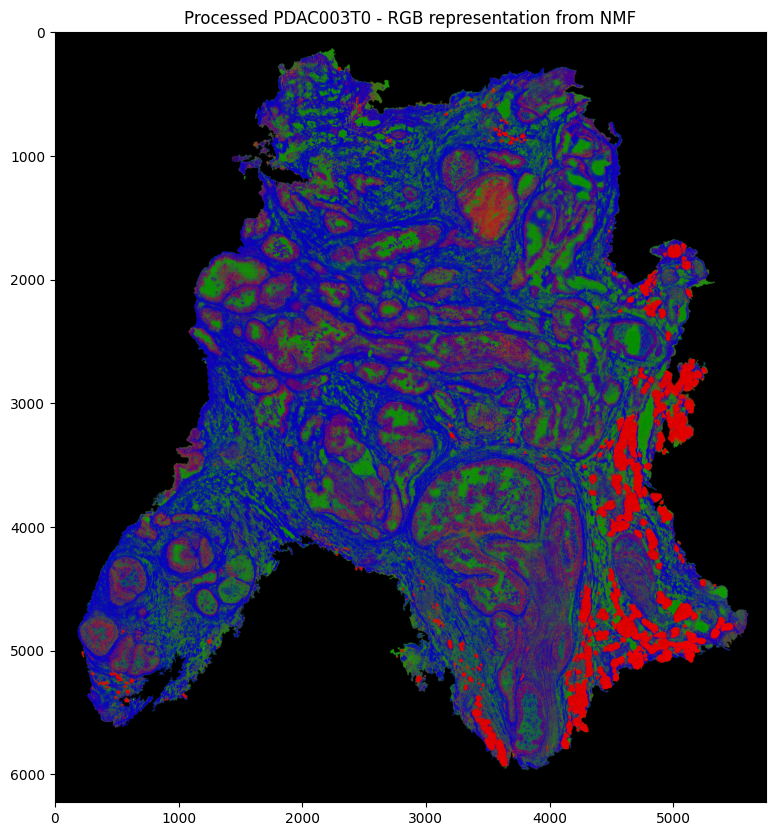

In [ ]:
for sample_id, output_file in processed_images.items():
    with tifffile.TiffReader(output_file) as tif:
        img = tif.asarray()
        img = img.transpose(1, 2, 0)  # Channels last
    
    rgb_image = convert_to_rgb(img)
    plt.figure(figsize=(10, 10))
    plt.imshow(rgb_image)
    plt.title(f"Processed {sample_id} - RGB representation from NMF")
    plt.savefig(os.path.join(PATH, "plots", "preprocessing", MODALITY_NAME, f"{sample_id}_rgb_nmf.svg"), dpi=300)
    plt.show()
    plt.close()

## Test

In [5]:
# Load images
images: list[np.ndarray] = []

for sample_id in SAMPLE_ID_LIST:
    with tifffile.TiffReader(os.path.join(PATH, sample_id, "preprocessing", MODALITY_NAME, f"{sample_id}.ome.tiff")) as tif:
        image = tif.asarray().transpose(1, 2, 0)  # Convert to H,W,C
        images.append(image)

# Normalize the images globally
min_val = min(image.min() for image in images)
max_val = max(image.max() for image in images)
for i in range(len(images)):
    images[i] = (images[i] - min_val) / (max_val - min_val)

In [6]:
import torch
from torch.utils.data import Dataset
import numpy as np

class HierarchicalPatchDataset(Dataset):
    def __init__(self, images, patch_size, group_size=4, transform=None):
        """
        Args:
            images (list of np.ndarray): Images of shape [H, W, channels]
            patch_size (int): size of small patches (e.g., 16)
            group_size (int): number of small patches per large patch (e.g., 4 for 64x64)
            transform (callable): transform applied only to original large patch to create transformed view
        """
        self.images = images
        self.patch_size = patch_size
        self.group_size = group_size
        self.transform = transform

        self.large_patch_size = patch_size * int(np.sqrt(group_size))

        # Hold precomputed data
        self.original_patches_groups = []
        self.transformed_patches_groups = []
        self.metadata = []

        self._precompute_all()

    def _pad_image(self, img):
        H, W, C = img.shape
        pad_h = (self.large_patch_size - H % self.large_patch_size) % self.large_patch_size
        pad_w = (self.large_patch_size - W % self.large_patch_size) % self.large_patch_size
        return np.pad(img,
                      ((0, pad_h), (0, pad_w), (0, 0)),
                      mode='constant', constant_values=0)

    def _split_into_patches(self, large_patch_np):
        grid_size = int(np.sqrt(self.group_size))
        patches = []
        for i in range(grid_size):
            for j in range(grid_size):
                y0 = i * self.patch_size
                x0 = j * self.patch_size
                small_patch_np = large_patch_np[y0:y0+self.patch_size, x0:x0+self.patch_size, :]
                patches.append(torch.tensor(small_patch_np, dtype=torch.float32))
        return torch.stack(patches, dim=0)  # [group_size, patch_size, patch_size, channels]

    def _precompute_all(self):
        for sample_idx, img in enumerate(self.images):
            padded_img = self._pad_image(img)
            H, W, _ = padded_img.shape
            grid_size = int(np.sqrt(self.group_size))

            for y in range(0, H, self.large_patch_size):
                for x in range(0, W, self.large_patch_size):
                    large_patch_np = padded_img[y:y+self.large_patch_size, x:x+self.large_patch_size, :]

                    # Precompute original patch group
                    original_patches_tensor = self._split_into_patches(large_patch_np)

                    # Precompute transformed patch group by transforming entire large patch
                    if self.transform is not None:
                        large_patch_tensor = torch.tensor(large_patch_np, dtype=torch.float32)
                        transformed_large_patch = self.transform(large_patch_tensor).numpy()
                    else:
                        transformed_large_patch = large_patch_np
                    transformed_patches_tensor = self._split_into_patches(transformed_large_patch)

                    self.original_patches_groups.append(original_patches_tensor)
                    self.transformed_patches_groups.append(transformed_patches_tensor)
                    self.metadata.append({
                        'sample_id': sample_idx,
                        'top_left': (y, x),
                        'center': (y + self.large_patch_size / 2, x + self.large_patch_size / 2)
                    })

    def __len__(self):
        return len(self.original_patches_groups)

    def __getitem__(self, idx):
        # Return precomputed paired patch groups: original and transformed
        return (self.original_patches_groups[idx], self.transformed_patches_groups[idx]), self.metadata[idx]


In [7]:
import torch
import torch.nn as nn

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len):  # max_len includes CLS token
        super().__init__()
        self.pos_embed = nn.Parameter(torch.randn(1, max_len, d_model))

    def forward(self, x):
        # x shape: [batch_size, seq_len+1, d_model]
        return x + self.pos_embed[:, :x.size(1), :]

class MaskedTransformerPatchAutoencoder(nn.Module):
    def __init__(self, patch_size=48, n_features=120, embed_dim=256, num_layers=6,
                 num_heads=8, dim_feedforward=512, dropout=0.1, mask_token=None):
        super().__init__()
        self.patch_size = patch_size
        self.n_features = n_features
        self.seq_len = patch_size * patch_size
        self.embed_dim = embed_dim

        # Input projection: patch pixels to embedding space
        self.input_proj = nn.Linear(n_features, embed_dim)

        # CLS token (learnable)
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))

        # Positional encoding for seq_len + 1 (CLS token)
        self.pos_encoding = PositionalEncoding(embed_dim, max_len=self.seq_len + 1)

        # Transformer encoder layers
        encoder_layer = nn.TransformerEncoderLayer(embed_dim, num_heads, dim_feedforward, dropout, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Transformer decoder layers
        decoder_layer = nn.TransformerEncoderLayer(embed_dim, num_heads, dim_feedforward, dropout, batch_first=True)
        self.decoder_transformer = nn.TransformerEncoder(decoder_layer, num_layers=num_layers)

        # Output linear layer to project embeddings back to pixel features
        self.output_proj = nn.Linear(embed_dim, n_features)

        # Mask token: learnable or zero vector if none provided
        if mask_token is None:
            self.mask_token = nn.Parameter(torch.zeros(1, 1, embed_dim))  # initialized to zeros
        else:
            self.mask_token = mask_token

    def forward(self, x, mask_ratio=0.3):
        """
        Args:
            x: [B, patch_size, patch_size, n_features] - input patches
            mask_ratio: float - fraction of tokens to mask
        Returns:
            cls_embedding: [B, embed_dim] - learned patch embedding
            reconstructed_patch: [B, patch_size, patch_size, n_features] - reconstruction output
            patch_tokens: [B, seq_len, embed_dim] - encoded patch tokens (no CLS)
        """
        batch = x.size(0)

        # Flatten patch spatial dims to sequence
        x_seq = x.view(batch, self.seq_len, self.n_features)  # [B, seq_len, n_features]

        # Project input pixels to embedding dimension
        x_emb = self.input_proj(x_seq)  # [B, seq_len, embed_dim]

        # Create random mask per batch
        num_mask = int(self.seq_len * mask_ratio)
        device = x.device
        mask = torch.zeros(batch, self.seq_len, dtype=torch.bool, device=device)
        for i in range(batch):
            perm = torch.randperm(self.seq_len, device=device)
            mask[i, perm[:num_mask]] = True

        # Replace masked tokens with mask token embedding
        x_emb_masked = x_emb.clone()
        x_emb_masked[mask] = self.mask_token.expand(batch, num_mask, self.embed_dim).contiguous().view(-1, self.embed_dim)

        # Prepare CLS token and concatenate
        cls_tokens = self.cls_token.expand(batch, -1, -1)  # [B,1,embed_dim]
        x_in = torch.cat([cls_tokens, x_emb_masked], dim=1)  # [B, seq_len+1, embed_dim]

        # Add positional encoding
        x_in = self.pos_encoding(x_in)  # [B, seq_len+1, embed_dim]

        # Transformer encoder
        encoded = self.encoder(x_in)  # [B, seq_len+1, embed_dim]

        # CLS embedding summary vector
        cls_embedding = encoded[:, 0, :]  # [B, embed_dim]

        # Extract token embeddings (excluding CLS)
        patch_tokens = encoded[:, 1:, :]  # [B, seq_len, embed_dim]

        # Transformer decoder reconstructs sequence embeddings
        decoded_seq = self.decoder_transformer(patch_tokens)  # [B, seq_len, embed_dim]

        # Project embeddings back to pixel space (sequence)
        output_tokens = self.output_proj(decoded_seq)  # [B, seq_len, n_features]

        # Reshape back to patch shape
        reconstructed_patch = output_tokens.view(batch, self.patch_size, self.patch_size, self.n_features)

        return cls_embedding, reconstructed_patch, patch_tokens, mask


In [8]:
import torch
import torch.nn as nn

class CLSAggregatorMaskedTransformer(nn.Module):
    def __init__(self, embed_dim, num_patches_per_group=4, num_heads=4,
                 num_layers=2, dim_feedforward=512, dropout=0.1, mask_ratio=0.3):
        """
        Transformer-based CLS aggregator with masking strategy and reconstruction head.

        Args:
            embed_dim (int): Dimensionality of input CLS token embeddings.
            num_patches_per_group (int): Number of CLS tokens to aggregate (e.g., 4 for 2x2 grid).
            num_heads (int): Number of attention heads in transformer layers.
            num_layers (int): Number of transformer encoder layers.
            dim_feedforward (int): Feedforward network hidden size in transformer layers.
            dropout (float): Dropout rate.
            mask_ratio (float): Fraction of CLS tokens to mask during training.
        """
        super().__init__()

        self.embed_dim = embed_dim
        self.num_tokens = num_patches_per_group
        self.mask_ratio = mask_ratio

        # CLS token (learnable)
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))

        # Positional encoding for num_tokens + 1 (CLS token)
        self.pos_embed = nn.Parameter(torch.randn(1, self.num_tokens + 1, embed_dim))

        # Transformer encoder for aggregation
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Learnable mask token for masking CLS tokens
        self.mask_token = nn.Parameter(torch.zeros(1, 1, embed_dim))

        # Decoder head: reconstruct input CLS token sequence from aggregated CLS embedding
        self.decoder_head = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * num_patches_per_group),
            nn.ReLU(),
            nn.Linear(embed_dim * num_patches_per_group, embed_dim * num_patches_per_group),
        )

    def forward(self, cls_tokens):
        """
        Args:
            cls_tokens: tensor of shape [batch_size, num_tokens, embed_dim]
              — CLS embeddings from smaller patches to aggregate.

        Returns:
            aggregated_cls: tensor of shape [batch_size, embed_dim]
              — single embedding summarizing the group of patches.
            decoded_seq: tensor of shape [batch_size, num_tokens, embed_dim]
              — reconstruction of the CLS tokens sequence.
            mask: boolean tensor [batch_size, num_tokens], indicating masked tokens during training.
        """
        batch_size = cls_tokens.size(0)
        device = cls_tokens.device

        # Prepare CLS token and concatenate
        cls_tokens_with_token = self.cls_token.expand(batch_size, -1, -1)  # [B,1,embed_dim]
        x = torch.cat([cls_tokens_with_token, cls_tokens], dim=1)  # [B, num_tokens+1, embed_dim]

        # Apply positional encoding
        x = x + self.pos_embed[:, :x.size(1), :]

        # During training apply masking
        if self.training:
            num_mask = int(self.num_tokens * self.mask_ratio)
            # Create mask per sample (only mask patch CLS tokens, not the global CLS token at pos 0)
            mask = torch.zeros(batch_size, self.num_tokens, dtype=torch.bool, device=device)
            for i in range(batch_size):
                perm = torch.randperm(self.num_tokens, device=device)
                mask[i, perm[:num_mask]] = True
            # Replace masked tokens with mask token embedding
            mask_token_expanded = self.mask_token.expand(batch_size, num_mask, self.embed_dim)
            for i in range(batch_size):
                x[i, 1:][mask[i]] = mask_token_expanded[i, :mask[i].sum()]
        else:
            mask = None  # no masking during eval

        # Pass through transformer encoder
        encoded = self.encoder(x)  # [B, num_tokens+1, embed_dim]

        # Output global CLS token summary embedding (index 0)
        aggregated_cls = encoded[:, 0, :]  # [B, embed_dim]

        # Decode aggregated CLS embedding back to sequence of CLS tokens
        decoded_seq = self.decoder_head(aggregated_cls)  # [B, embed_dim * num_tokens]
        decoded_seq = decoded_seq.view(batch_size, self.num_tokens, self.embed_dim)  # [B, num_tokens, embed_dim]

        return aggregated_cls, decoded_seq, mask


In [9]:
class RandomRotate:
    def __call__(self, patch):
        # patch shape: [h, w, n_features]
        # Convert to [n_features, h, w] for torchvision
        patch = patch.permute(2, 0, 1)
        k = torch.randint(0, 4, (1,)).item()
        patch = torch.rot90(patch, k, [1, 2])
        # Back to [h, w, n_features]
        patch = patch.permute(1, 2, 0)
        return patch

In [10]:
import torch.nn.functional as F
def nt_xent_loss(z_i, z_j, temperature=0.5):
    z_i = z_i.reshape(-1, z_i.size(-1))
    z_j = z_j.reshape(-1, z_j.size(-1))
    batch_size = z_i.size(0)
    z = torch.cat([z_i, z_j], dim=0)
    sim = F.cosine_similarity(z.unsqueeze(1), z.unsqueeze(0), dim=-1)

    mask = torch.eye(2 * batch_size, dtype=torch.bool, device=z.device)
    sim = sim / temperature

    positives = torch.cat([torch.arange(batch_size, 2 * batch_size),
                           torch.arange(0, batch_size)]).to(z.device)
    pos_sim = sim[torch.arange(2 * batch_size), positives]

    sim = sim.masked_fill(mask, float('-inf'))

    log_prob = pos_sim - torch.logsumexp(sim, dim=1)
    loss = -log_prob.mean()
    return loss

In [12]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
import tqdm

# Assume nt_xent_loss is defined elsewhere

def masked_reconstruction_loss(output, target, mask):
    diff = (output - target) ** 2
    masked_diff = diff[mask]
    return masked_diff.mean()

# Hyperparameters
patch_size = 16  # base patch size
group_size = 4   # number of small patches to aggregate
embedding_size = 128
batch_size = 4
num_epochs = 20
learning_rate = 1e-4
lambda_embed = 1e-4
lambda_contrast = 0.5
lambda_agg_recon = 1e-3
lambda_agg_embed = 1e-4
lambda_agg_contrast = 0.5

# Dataset and DataLoader
transform = RandomRotate()
dataset = HierarchicalPatchDataset(images, patch_size=patch_size, group_size=group_size, transform=transform)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

# Initialize models
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
patch_encoder = MaskedTransformerPatchAutoencoder(patch_size, images[0].shape[2], embedding_size).to(device)
cls_aggregator = CLSAggregatorMaskedTransformer(embed_dim=embedding_size, num_patches_per_group=group_size).to(device)

optimizer = torch.optim.Adam(list(patch_encoder.parameters()) + list(cls_aggregator.parameters()), lr=learning_rate)

for epoch in range(num_epochs):
    epoch_loss = 0.0
    patch_encoder.train()
    cls_aggregator.train()

    for (patches_orig, patches_transf), _ in tqdm.tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}", unit="batch"):

        optimizer.zero_grad()

        B, grp_sz, H, W, n_features = patches_orig.shape

        cls_embed_group_orig = []
        cls_embed_group_transf = []
        patch_losses = []

        for patch_idx in range(grp_sz):

            # Extract individual patches
            patch_orig = patches_orig[:, patch_idx, :, :, :].clone()  # [B, H, W, F]
            patch_transf = patches_transf[:, patch_idx, :, :, :].clone()  # [B, H, W, F]

            patch_orig = patch_orig.to(device)
            patch_transf = patch_transf.to(device)

            # Forward patch encoder on both views (with masking) for each individual patch
            cls_embed_orig, reconstructed_orig, patch_tokens_orig, mask_orig = patch_encoder(patch_orig)
            cls_embed_transf, reconstructed_transf, patch_tokens_transf, mask_transf = patch_encoder(patch_transf)

            # cls_embed_orig has shape [B, embedding_size]
            # cls_embed_transf has shape [B, embedding_size]
            # reconstructed_orig has shape [B, H, W, F]
            # reconstructed_transf has shape [B, H, W, F]
            # patch_tokens_orig has shape [B, H*W, embedding_size]
            # patch_tokens_transf has shape [B, H*W, embedding_size]

            # Reconstruction loss on masked tokens for both views
            loss_recon_orig = masked_reconstruction_loss(
                reconstructed_orig.view(B, -1, n_features),
                patch_transf.view(B, -1, n_features),
                mask_orig
            )
            loss_recon_transf = masked_reconstruction_loss(
                reconstructed_transf.view(B, -1, n_features),
                patch_transf.view(B, -1, n_features),
                mask_transf
            )
            loss_recon = 0.5 * (loss_recon_orig + loss_recon_transf)
            del patch_orig, patch_transf, reconstructed_orig, reconstructed_transf  # free memory

            # Embedding L2 regularization on patch tokens (averaged)
            loss_embed = 0.5 * (torch.mean(torch.norm(patch_tokens_orig, dim=-1)) + torch.mean(torch.norm(patch_tokens_transf, dim=-1)))

            # Contrastive loss on patch tokens between views
            loss_contrast_patch = nt_xent_loss(patch_tokens_orig, patch_tokens_transf)

            # Accumulate CLS embeddings for aggregator
            cls_embed_group_orig.append(cls_embed_orig)
            cls_embed_group_transf.append(cls_embed_transf)

            # Accumulate patch-level losses
            patch_losses.append(loss_recon + lambda_embed * loss_embed + lambda_contrast * loss_contrast_patch)
            del cls_embed_orig, cls_embed_transf, patch_tokens_orig, patch_tokens_transf  # free memory

        # Average patch-level losses
        patches_total_loss = torch.stack(patch_losses).mean()

        # Stack CLS embeddings for the group
        cls_embed_orig = torch.stack(cls_embed_group_orig, dim=1)  # [B, group_size, embedding_size]
        cls_embed_transf = torch.stack(cls_embed_group_transf, dim=1)  # [B, group_size, embedding_size]

        # Forward CLS aggregator on both views
        aggregated_cls_orig, decoded_cls_seq_orig, agg_mask_orig = cls_aggregator(cls_embed_orig)
        aggregated_cls_transf, decoded_cls_seq_transf, agg_mask_transf = cls_aggregator(cls_embed_transf)

        # Aggregator reconstruction loss on masked tokens (average both views)
        loss_recon_orig = masked_reconstruction_loss(
            decoded_cls_seq_orig, cls_embed_orig, agg_mask_orig
        )
        loss_recon_transf = masked_reconstruction_loss(
            decoded_cls_seq_transf, cls_embed_transf, agg_mask_transf
        )
        loss_agg_recon = 0.5 * (loss_recon_orig + loss_recon_transf)

        # Aggregated CLS embedding regularization (averaged)
        loss_agg_embed = 0.5 * (torch.norm(aggregated_cls_orig, dim=1).mean() + torch.norm(aggregated_cls_transf, dim=1).mean())

        # Contrastive loss on patch CLS embeddings (flatten batch)
        loss_contrast = nt_xent_loss(
            cls_embed_orig.view(B * grp_sz, embedding_size),
            cls_embed_transf.view(B * grp_sz, embedding_size)
        )

        # Contrastive loss on aggregated CLS embeddings
        loss_agg_contrast = nt_xent_loss(aggregated_cls_orig, aggregated_cls_transf)

        # Final combined loss
        total_loss = (
            patches_total_loss
            + lambda_agg_recon * loss_agg_recon
            + lambda_agg_embed * loss_agg_embed
            + lambda_contrast * loss_contrast
            + lambda_agg_contrast * loss_agg_contrast  # uncomment if used
        )

        total_loss.backward()
        optimizer.step()

        epoch_loss += total_loss.item() * B

    avg_loss = epoch_loss / len(dataset)
    print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {avg_loss:.6f}")


Epoch 1/20:   0%|          | 44/11591 [00:15<1:06:42,  2.88batch/s]


KeyboardInterrupt: 

In [23]:
import torch
from collections import defaultdict
import tqdm

def collate_fn(batch):
    # batch: list of ((patch_view1, patch_view2), metadata)
    # Use first augmented view for inference embeddings
    patches_view1 = torch.stack([item[0][0] for item in batch], dim=0)
    metadatas = [item[1] for item in batch]
    return patches_view1, metadatas

def inference_embeddings(model, dataset, device):
    dataloader = torch.utils.data.DataLoader(
        dataset, batch_size=64, shuffle=False, collate_fn=collate_fn
    )

    model.eval()
    embeddings_by_image = defaultdict(list)
    metadata_by_image = defaultdict(list)

    with torch.no_grad():
        for patches, metadatas in tqdm.tqdm(dataloader):
            patches = patches.to(device)  # [B, patch_size, patch_size, n_features]

            # Model returns: cls_embedding, reconstructed_patch, patch_tokens, mask
            cls_embeddings, _, _, _ = model(patches)  # cls_embeddings: [B, embed_dim]

            embeddings = cls_embeddings.cpu()

            for i, meta in enumerate(metadatas):
                sample_id = meta['sample_id']
                embeddings_by_image[sample_id].append(embeddings[i])
                metadata_by_image[sample_id].append(meta)

    # Convert lists of embeddings to stacked tensors per image
    embeddings_by_image = {k: torch.stack(v) for k, v in embeddings_by_image.items()}
    return embeddings_by_image, metadata_by_image

# Usage example
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
embeddings_dict, metadata_dict = inference_embeddings(model, dataset, device)

# embeddings_dict[image_idx]: tensor of shape [num_patches, embedding_dim]
# metadata_dict[image_idx]: list of metadata dicts for each patch


100%|██████████| 1500/1500 [00:18<00:00, 79.54it/s]


In [24]:
adata_list = []
for image_idx, sample_id in enumerate(SAMPLE_ID_LIST):
    embeddings = embeddings_dict[image_idx].numpy()  # [num_patches, embedding_dim]
    metadata = metadata_dict[image_idx]
    
    # Create AnnData
    adata = ad.AnnData(X=embeddings)
    
    # Add metadata
    centers = np.array([meta['center'] for meta in metadata])
    

    adata.obs['sample_id'] = sample_id
    adata.obsm['spatial'] = centers  # Store spatial coordinates in obsm

    adata.obs_names = [f"{sample_id}_{i}" for i in range(adata.n_obs)]
    adata.var_names = [f"{i}" for i in range(adata.n_vars)]
    
    adata_list.append(adata)

In [25]:
raman_dataset = ad.concat(adata_list)



In [26]:
raman_dataset.obs['sample_id'].unique()

array(['PDAC010T0'], dtype=object)

In [27]:
# PCA and UMAP
sc.pp.pca(raman_dataset, n_comps=50)

In [28]:
sc.pp.neighbors(raman_dataset, n_neighbors=50)
sc.tl.umap(raman_dataset)

In [29]:
# Leiden clustering
sc.tl.leiden(raman_dataset, resolution=0.25)

/tmp/ipykernel_3217138/2263447407.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(raman_dataset, resolution=0.25)


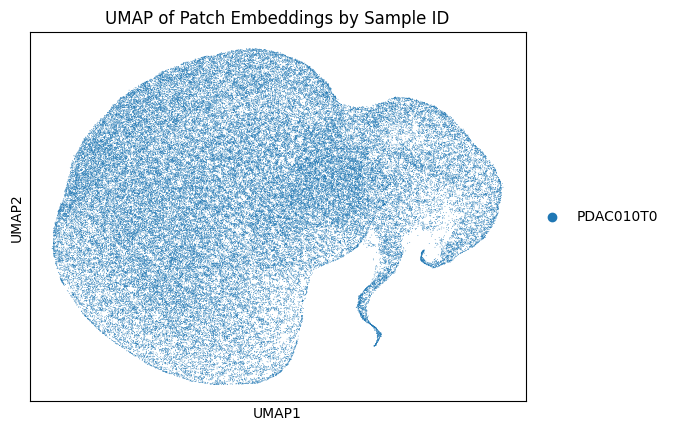

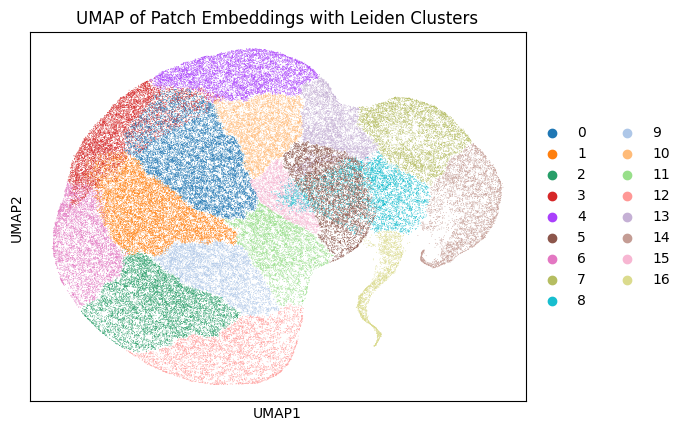

In [30]:
# Plot UMAP
sc.pl.umap(raman_dataset, color=['sample_id'], title='UMAP of Patch Embeddings by Sample ID')
sc.pl.umap(raman_dataset, color=['leiden'], title='UMAP of Patch Embeddings with Leiden Clusters')

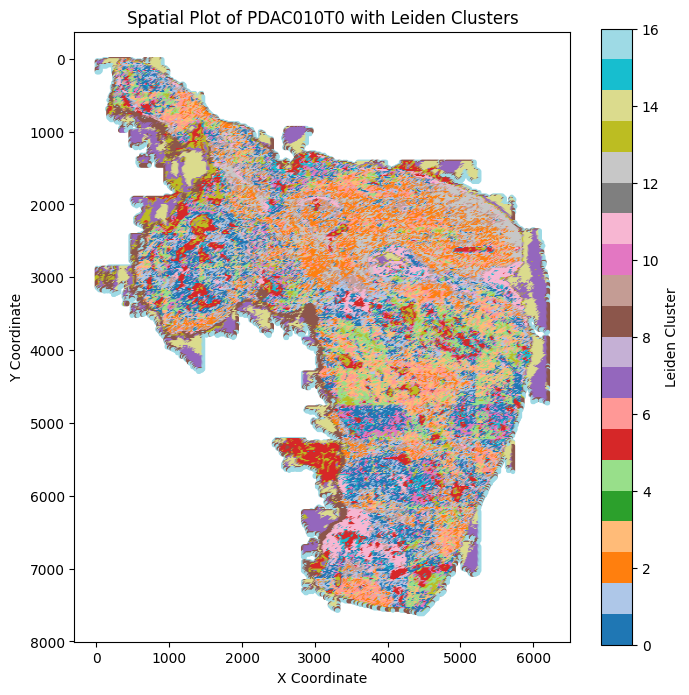

In [32]:
# Create scatter plot
for sample_id in SAMPLE_ID_LIST:
    plt.figure(figsize=(8, 8))

    # Keep the aspect ratio equal
    plt.gca().set_aspect('equal', adjustable='box')

    plt.scatter(
        raman_dataset.obsm['spatial'][raman_dataset.obs['sample_id'] == sample_id][:, 1],
        raman_dataset.obsm['spatial'][raman_dataset.obs['sample_id'] == sample_id][:, 0],
        c=raman_dataset.obs['leiden'][raman_dataset.obs['sample_id'] == sample_id].astype(int),
        cmap='tab20',
        s=5,
    )
    plt.title(f'Spatial Plot of {sample_id} with Leiden Clusters')
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.colorbar(label='Leiden Cluster')
    
    # Invert y-axis to match image coordinates
    plt.gca().invert_yaxis()
    plt.show()
    plt.close()